<a href="https://colab.research.google.com/github/eman-alsayed-hasan/DATATSC-ENCE-ECOSYSTEM/blob/main/part1_evidence_synthesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# We need to install the following packages to run the code in this notebook
# This should take about 1 to 2 minutes.
# %%capture
!pip install datasets
!pip install transformers
!pip install accelerate

In [2]:
import pandas as pd
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt
import numpy as np
import re

# Here we will download the openalex dataset from the huggingface hub.
filepath = hf_hub_download(repo_id="dspoka/ccai-nlp-tutorial-1", filename="openalex_data.csv", repo_type="dataset")
with open(filepath) as f:
    unlabeled_data = pd.read_csv(f)


print(f'The dataset has {unlabeled_data.shape[0]} rows and {unlabeled_data.shape[1]} columns')
print(f'The columns are: {unlabeled_data.columns.values}')
unlabeled_data.head()

openalex_data.csv:   0%|          | 0.00/28.1M [00:00<?, ?B/s]

The dataset has 24906 rows and 6 columns
The columns are: ['id' 'doi' 'title' 'publication_year' 'abstract' 'authors']


,id,doi,title,publication_year,abstract,authors
0,https://openalex.org/W2076977109,https://doi.org/10.1038/nature03906,Increasing destructiveness of tropical cyclone...,2005,NaN,Kerry Emanuel
1,https://openalex.org/W2171979944,https://doi.org/10.1007/s00425-003-1105-5,"Plant responses to drought, salinity and extre...",2003,NaN,"Wang-Xia Wang, Basia Vinocur, Arie Altman"
2,https://openalex.org/W2122582889,https://doi.org/10.1073/pnas.0505734102,Regional vegetation die-off in response to glo...,2005,Future drought is projected to occur under war...,"David D. Breshears, Neil S. Cobb, Paul Rich, K..."
3,https://openalex.org/W2170327428,https://doi.org/10.1073/pnas.1422385112,Anthropogenic warming has increased drought ri...,2015,Significance California ranks first in the Uni...,"Noah S. Diffenbaugh, Daniel L. Swain, Danielle..."
4,https://openalex.org/W2154180993,https://doi.org/10.1038/nature04188,Impact of regional climate change on human health,2005,NaN,"Jonathan A. Patz, Diarmid Campbell-Lendrum, Tr..."


(24906, 6)


<Axes: xlabel='publication_year'>

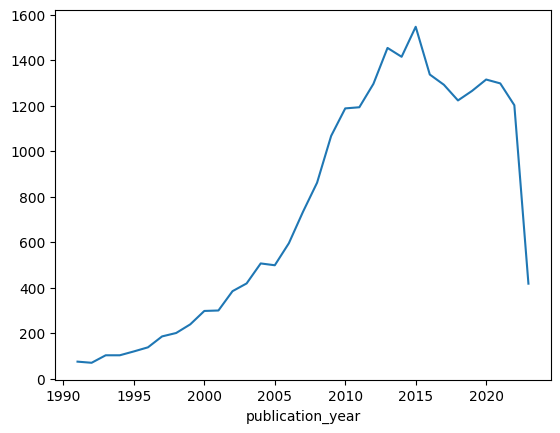

In [3]:
print(unlabeled_data.shape)
unlabeled_data.query("publication_year>1990").groupby("publication_year")["id"].count().plot()

In [4]:
filepath = hf_hub_download(repo_id="dspoka/ccai-nlp-tutorial-1", filename="labelled_data.csv", repo_type="dataset")
with open(filepath) as f:
    labeled_data = pd.read_csv(f)

# We create a lower case version of the title without spaces and punctuation, to allow for merging
labeled_data["title_lcase"] = labeled_data["title"].apply(lambda x: re.sub("\W", "", x).lower() if isinstance(x, str) else x)

# We also want to get rid of documents without abstracts, as we can't use these for learning
labeled_data = labeled_data.dropna(subset=["abstract"])
print(labeled_data.shape)
labeled_data.head()

<>:6: SyntaxWarning: invalid escape sequence '\W'
<>:6: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipykernel_421/341116838.py:6: SyntaxWarning: invalid escape sequence '\W'
  labeled_data["title_lcase"] = labeled_data["title"].apply(lambda x: re.sub("\W", "", x).lower() if isinstance(x, str) else x)


labelled_data.csv:   0%|          | 0.00/4.45M [00:00<?, ?B/s]

(2500, 11)


,id,abstract,title,seen,INCLUDE,12 - Coastal and marine Ecosystems,12 - Human and managed,"12 - Mountains, snow and ice","12 - Rivers, lakes, and soil moisture",12 - Terrestrial ES,title_lcase
0,1448689,"The city of Bismarck, North Dakota has one of ...",Key Factors Influencing the Incidence of West ...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,keyfactorsinfluencingtheincidenceofwestnilevir...
1,3281128,Changing precipitation regimes can profoundly ...,Asymmetric responses of plant community struct...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,asymmetricresponsesofplantcommunitystructurean...
2,900708,Climate influences forest structure through ef...,Climate effects on fire regimes and tree recru...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,climateeffectsonfireregimesandtreerecruitmenti...
3,3234419,"Climate change is likely to bring more, hotter...",Climate change adaptation and mitigation ? a h...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,climatechangeadaptationandmitigationahitherton...
4,2090028,Aim The long-term stability of coastal ecosyst...,Caribbean mangroves adjust to rising sea level...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,caribbeanmangrovesadjusttorisingsealevelthroug...


In [5]:
# Now we load the Open alex data, and create the same title variable for merging
unlabeled_data = unlabeled_data.rename(columns={"id": "OA_id"})
unlabeled_data["title_lcase"] = unlabeled_data["title"].apply(lambda x: re.sub("\W", "", x).lower() if isinstance(x, str) else x)
unlabeled_data = unlabeled_data.dropna(subset=["abstract"]).copy()
unlabeled_data.loc[:, "seen"] = 0
print(f'The dataset has {unlabeled_data.shape[0]} rows and {unlabeled_data.shape[1]} columns')
#unlabeled_data.head()

# Now we add the OpenAlex rows which are not in the labelled data to the labelled_data
# print(unlabeled_data[~unlabeled_data["title_lcase"].isin(labeled_data["title_lcase"])].shape)

df = pd.concat(
    [labeled_data, unlabeled_data[~unlabeled_data["title_lcase"].isin(labeled_data["title_lcase"])]]
)
print(df.shape)
df.head()

<>:3: SyntaxWarning: invalid escape sequence '\W'
<>:3: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipykernel_421/1841148473.py:3: SyntaxWarning: invalid escape sequence '\W'
  unlabeled_data["title_lcase"] = unlabeled_data["title"].apply(lambda x: re.sub("\W", "", x).lower() if isinstance(x, str) else x)


The dataset has 18556 rows and 8 columns
(20771, 15)


,id,abstract,title,seen,INCLUDE,12 - Coastal and marine Ecosystems,12 - Human and managed,"12 - Mountains, snow and ice","12 - Rivers, lakes, and soil moisture",12 - Terrestrial ES,title_lcase,OA_id,doi,publication_year,authors
0,1448689.0,"The city of Bismarck, North Dakota has one of ...",Key Factors Influencing the Incidence of West ...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,keyfactorsinfluencingtheincidenceofwestnilevir...,NaN,NaN,NaN,NaN
1,3281128.0,Changing precipitation regimes can profoundly ...,Asymmetric responses of plant community struct...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,asymmetricresponsesofplantcommunitystructurean...,NaN,NaN,NaN,NaN
2,900708.0,Climate influences forest structure through ef...,Climate effects on fire regimes and tree recru...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,climateeffectsonfireregimesandtreerecruitmenti...,NaN,NaN,NaN,NaN
3,3234419.0,"Climate change is likely to bring more, hotter...",Climate change adaptation and mitigation ? a h...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,climatechangeadaptationandmitigationahitherton...,NaN,NaN,NaN,NaN
4,2090028.0,Aim The long-term stability of coastal ecosyst...,Caribbean mangroves adjust to rising sea level...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,caribbeanmangrovesadjusttorisingsealevelthroug...,NaN,NaN,NaN,NaN


Number of seen vs. unseen documents
seen
0.0    18262
1.0     2500
Name: title, dtype: int64
--------------------------------------------------------------------------------
Number of included vs. excluded documents
INCLUDE
0.0    1194
1.0    1306
Name: title, dtype: int64


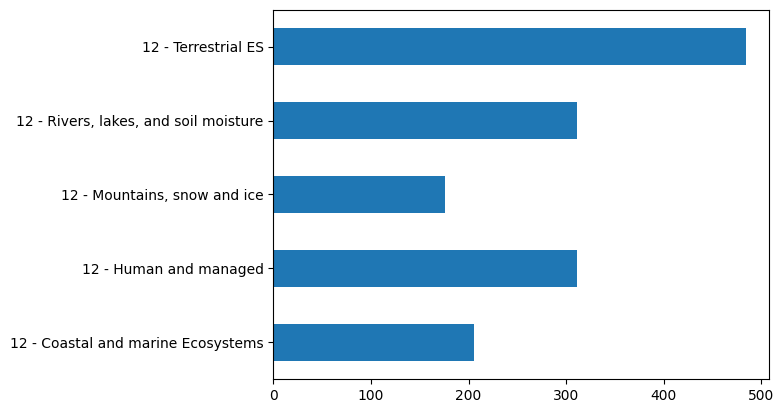

In [6]:
def inspect_labels(df):
    # We can quickly plot how many documents have been labelled, and how many not
    # df.groupby("seen")["title"].count().plot.bar();
    print('Number of seen vs. unseen documents')
    print(df.groupby("seen")["title"].count())
    print('-'*80)
    # and also plot how many of the labelled docs were included
    # df.groupby("INCLUDE")["title"].count().plot.bar()

    print('Number of included vs. excluded documents')
    print(df.groupby("INCLUDE")["title"].count())
    # Finally we can plot how many examples of each impact type we have
    df[impacts].sum().plot.barh();

impacts = [x for x in df.columns if re.match("12 -", x)]
inspect_labels(df)

In [7]:
from sklearn.model_selection import train_test_split
def train_test_split_df(df):
    ''' Gets train/test splits for INCLUDE prediction task.
    '''
    # select only the seen documents
    all_seen = df[df["seen"] == 1].sample(2000).index
    all_x = df[df["seen"] == 1]["abstract"].values
    all_y = df[df["seen"] == 1]["INCLUDE"].values.astype(int)
    # percent of data to use for train, val, test
    train_size = 0.8
    # train_size = 0.01
    # get the indices for each split
    x_train, x_test, y_train, y_test = train_test_split(all_x, all_y, train_size=train_size, random_state=42)
    assert len(x_train) == len(y_train)
    assert len(x_test) == len(y_test)
    print (f"Train size: {len(x_train)}")
    print (f"Test size: {len(x_test)}")
    return x_train, y_train, x_test, y_test

In [8]:
def visualize_doc_vec(X, features=None):
    '''Simple function to visualise a document-term matrix'''
    print('Document-term matrix:\n', X.todense())
    # And we could visualise this simply like this
    fig, ax = plt.subplots()
    doc_map = ax.imshow(X.todense(), cmap="Blues")
    ax.set_xticks(np.arange(len(features)))
    ax.set_xticklabels(features, rotation=45, ha="right")
    cbar = fig.colorbar(doc_map)
    plt.show()

from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


def show_raw_counts(texts):
    '''
    Function to show the raw counts of words in a corpus and visualize them.
    '''
    # We'll instantiate a vectorizer class
    vectorizer = CountVectorizer()

    # And apply the fit_transform method to our texts
    X = vectorizer.fit_transform(texts)

    # This gives us a matrix of shape n_texts, vocab_size
    X.todense()

    # The features each column represents can be accessed here
    features = vectorizer.get_feature_names_out()
    visualize_doc_vec(X, features)

Document-term matrix:
 [[0 0 1 1 0 0 1 1 1 0 0 1]
 [1 1 1 1 1 1 0 0 1 0 0 0]
 [0 0 2 1 0 0 0 0 0 1 1 0]]


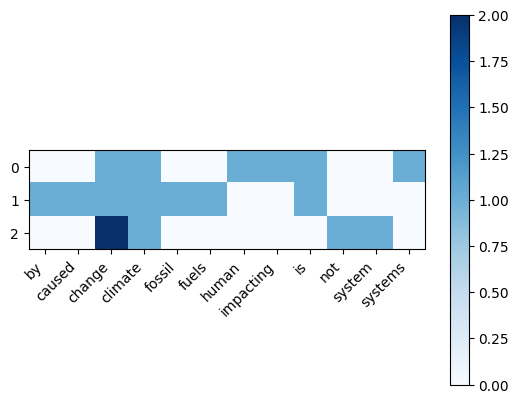

In [9]:
# Let's take for now a couple of example texts
texts = [
    "Climate change is impacting human systems",
    "Climate change is caused by fossil fuels",
    "System change not climate change",
]
# And now lets visualize the raw word counts in our 3 sentences.
show_raw_counts(texts)

In [10]:
def show_tfidf(texts):
    '''
    Function to show the tf-idf scores of words in a corpus and visualize them.
    '''
    # We'll instantiate a term frequency - inverse document frequency vectorizer class
    vectorizer = TfidfVectorizer()

    # And apply the fit_transform method to our texts
    X = vectorizer.fit_transform(texts)

    # This gives us a matrix of shape n_texts, vocab_size
    X.todense()

    # The features each column represents can be accessed here
    features = vectorizer.get_feature_names_out()
    visualize_doc_vec(X, features)

Document-term matrix:
 [[0.         0.         0.28561676 0.28561676 0.         0.
  0.48359121 0.48359121 0.36778358 0.         0.         0.48359121]
 [0.43535684 0.43535684 0.25712876 0.25712876 0.43535684 0.43535684
  0.         0.         0.3311001  0.         0.         0.        ]
 [0.         0.         0.61046311 0.30523155 0.         0.
  0.         0.         0.         0.51680194 0.51680194 0.        ]]


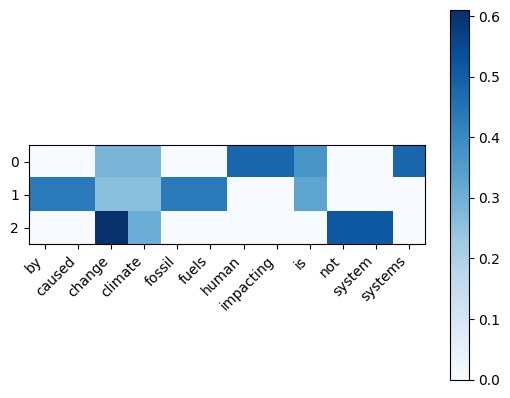

In [11]:
show_tfidf(texts)

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

def build_svm(toy_texts, y):
    '''
    Function to create a pipeline with a tf-idf vectorizer and a support vector machine classifier.
    '''
    svm_classifier = Pipeline(
        steps=[
            ("vect", TfidfVectorizer()),
            ("clf", SVC(probability=True, class_weight="balanced")),
        ]
    )
    svm_classifier.fit(toy_texts, y)
    return svm_classifier


# We'll slightly expand our list of texts
toy_texts, y = zip(
    *[
        ("Climate change is impacting human systems", 1),
        ("Climate change is caused by fossil fuels", 0),
        ("Agricultural yields are affected by climate change", 1),
        ("System change not climate change", 0),
        ("higher temperatures are impacting human health", 1),
        ("Forest fires are becoming more frequent due to climate change", 1),
        ("Machine learning can read texts", 0),
        ("AI can help solve climate change!", 0),
        ("We need to save gas this winter", 0),
        ("More frequent droughts are impacting crop yields", 1),
        ("Many communities are affected by rising sea levels", 1),
        ("Global emissions continue to rise", 0),
        ("Ecosystems are increasingly impacted by rising temperatures", 1),
        ("Emissions from fossil fuels need to decline", 0),
        ("Anthropogenic climate change is impacting vulnerable communities", 1),
    ]
)

# Now lets build a simple SVM classifier on this toy data

svm_classifier = build_svm(toy_texts, y)
svm_classifier

Pipeline(steps=[('vect', TfidfVectorizer()),
                ('clf', SVC(class_weight='balanced', probability=True))])

In [13]:
# We can now use this classifier to make predictions about new texts

# Here are a couple of easy examples (easy because they are similar to our examples)
new_texts = [
    "climate change is impacting terrestrial ecosystems",
    "Machine Learning will solve climate change",
    "Coca Cola is a company that produces sugary drinks",
]
# We can make predictions about which class the examples belong to
print('predictions:', svm_classifier.predict(new_texts))
# We can also get these as probabilities (which are very unstable with small datasets, and not guaranteed to match the predictions)
print('probabilities:\n', svm_classifier.predict_proba(new_texts))

predictions: [1 0 1]
probabilities:
 [[0.48678753 0.51321247]
 [0.43685422 0.56314578]
 [0.4701399  0.5298601 ]]


In [14]:
# Each row contains predicted probabilites for each class, in this case 0, and 1

# We can get predicted probabilities of being in the INCLUDE class like this
# One for each of the three examples
svm_classifier.predict_proba(new_texts)[:, 1]

array([0.51321247, 0.56314578, 0.5298601 ])

In [15]:
from sklearn.metrics import classification_report

def train_eval_svm(df):
    '''
    Function to that trains with train data and evalutes the model with test data.
    '''
    # load the train/test splits
    x_train, y_train, x_test, y_test = train_test_split_df(df)
    # build the classifier
    svm_classifier = build_svm(x_train, y_train)
    # get the predictions on the test set
    test_pred = svm_classifier.predict(x_test)
    # Get the classification evaluation metrics
    # This will be covered in more detail later.
    print(classification_report(y_test, test_pred))

In [16]:
# So far this was an illustrative example using toy data. Let's now apply this to our real data.
# takes around 20 seconds to run
train_eval_svm(df)

Train size: 2000
Test size: 500
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       235
           1       0.82      0.87      0.84       265

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



In [17]:
# Show the different classes of impacts.
print(impacts)
df[df["INCLUDE"] == 1].head()

['12 - Coastal and marine Ecosystems', '12 - Human and managed', '12 - Mountains, snow and ice', '12 - Rivers, lakes, and soil moisture', '12 - Terrestrial ES']


,id,abstract,title,seen,INCLUDE,12 - Coastal and marine Ecosystems,12 - Human and managed,"12 - Mountains, snow and ice","12 - Rivers, lakes, and soil moisture",12 - Terrestrial ES,title_lcase,OA_id,doi,publication_year,authors
1,3281128.0,Changing precipitation regimes can profoundly ...,Asymmetric responses of plant community struct...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,asymmetricresponsesofplantcommunitystructurean...,NaN,NaN,NaN,NaN
2,900708.0,Climate influences forest structure through ef...,Climate effects on fire regimes and tree recru...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,climateeffectsonfireregimesandtreerecruitmenti...,NaN,NaN,NaN,NaN
3,3234419.0,"Climate change is likely to bring more, hotter...",Climate change adaptation and mitigation ? a h...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,climatechangeadaptationandmitigationahitherton...,NaN,NaN,NaN,NaN
4,2090028.0,Aim The long-term stability of coastal ecosyst...,Caribbean mangroves adjust to rising sea level...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,caribbeanmangrovesadjusttorisingsealevelthroug...,NaN,NaN,NaN,NaN
5,574391.0,Climate change and habitat destruction have be...,Compounded effects of climate change and habit...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,compoundedeffectsofclimatechangeandhabitatalte...,NaN,NaN,NaN,NaN


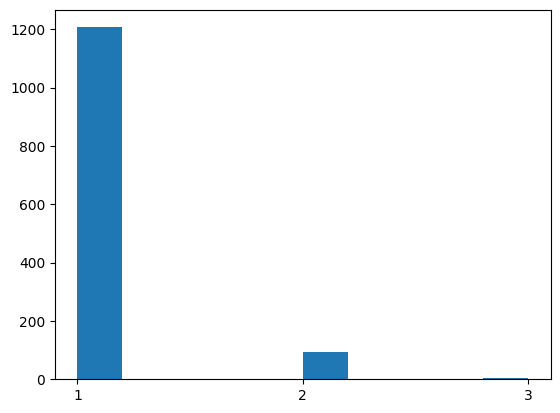

In [18]:
# This plot shows that certain documents have multiple labels for different impacts.
plt.hist(df[df["INCLUDE"] == 1][impacts].sum(axis=1))
plt.xticks(np.arange(1, 4, 1))
plt.show()

In [19]:
# create an x and y variable with a sample of 200 relevant documents
samples = df[df["INCLUDE"] == 1].sample(200).index
X = df.iloc[samples]["abstract"]
y = df.iloc[samples][impacts].values
np.set_printoptions(threshold=5)
y

array([[0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 1.]])

In [20]:
from sklearn.multiclass import OneVsRestClassifier

clf = Pipeline(
    steps=[
        ("vec", TfidfVectorizer()),
        ("clf", OneVsRestClassifier(SVC(probability=True, class_weight="balanced"))),
    ]
)

clf.fit(X, y)

Pipeline(steps=[('vec', TfidfVectorizer()),
                ('clf',
                 OneVsRestClassifier(estimator=SVC(class_weight='balanced',
                                                   probability=True)))])

In [21]:
example_texts = [
    "Climate change has affected butterfly phenology in North America. "
    + "In an experiment in the butterfly national park, we found that "
    + "mean dates of appearance had shifted by two weeks. Species traits, "
    + "especially ecological traits, were found to explain some part of "
    + "different phenological responses",

    "Rising temperatures have contributed to increasing heat related mortaility "
    + "in cities across Europe. ",
]
y_pred = clf.predict(example_texts)

pd.DataFrame(y_pred, columns=impacts)

,12 - Coastal and marine Ecosystems,12 - Human and managed,"12 - Mountains, snow and ice","12 - Rivers, lakes, and soil moisture",12 - Terrestrial ES
0,0,0,0,0,1
1,0,0,0,0,0


In [22]:
example_texts = [
    "Climate change has affected butterfly phenology in North America. "
    + "In an experiment in the butterfly national park, we found that "
    + "mean dates of appearance had shifted by two weeks. Species traits, "
    + "especially ecological traits, were found to explain some part of "
    + "different phenological responses",

    "Rising temperatures have contributed to increasing heat related mortaility "
    + "in cities across Europe. ",
]
y_pred = clf.predict(example_texts)

pd.DataFrame(y_pred, columns=impacts)

,12 - Coastal and marine Ecosystems,12 - Human and managed,"12 - Mountains, snow and ice","12 - Rivers, lakes, and soil moisture",12 - Terrestrial ES
0,0,0,0,0,1
1,0,0,0,0,0


In [23]:
# Let's take our texts and our labels again
# Each example is a tuple of (text, label)
# Where a label is 1 if the text is relevant and should be included in a synthesis report and 0 otherwise
texts, y = zip(
    *[
        ("Climate change is impacting human systems", 1),
        ("Climate change is caused by fossil fuels", 0),
        ("Agricultural yields are affected by climate change", 1),
        ("System change not climate change", 0),
        ("higher temperatures are impacting human health", 1),
        ("Forest fires are becoming more frequent due to climate change", 1),
        ("Machine learning can read texts", 0),
        ("AI can help solve climate change!", 0),
        ("We need to save gas this winter", 0),
        ("More frequent droughts are impacting crop yields", 1),
        ("Many communities are affected by rising sea levels", 1),
        ("Global emissions continue to rise", 0),
        ("Ecosystems are increasingly impacted by rising temperatures", 1),
        ("Emissions from fossil fuels need to decline", 0),
        ("Anthropogenic climate change is impacting vulnerable communities", 1),
    ]
)

In [24]:
# To use these with transformers, we are going to need to get them into the right format.
from datasets import Dataset
from transformers import AutoTokenizer

# First we'll put them into a HuggingFace Dataset object
dataset = Dataset.from_dict({"text": texts, "label": y})

# And now we need to tokenize the texts, using the pretrained tokenizer from climatebert
model_name = "climatebert/distilroberta-base-climate-f"
tokenizer = AutoTokenizer.from_pretrained(model_name)


def tokenize_function(examples):
    return tokenizer(examples["text"], padding="longest", truncation=True)


tokenized_dataset = dataset.map(tokenize_function, batched=True)
# input_ids are the token ids for each token in the text
# attention_mask is a mask that tells the model which tokens to pay attention to and which to ignore
# Note the attention mask has 0s for padded tokens.
tokenized_dataset[0]

config.json:   0%|          | 0.00/752 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.46k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.15M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/4.98k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

{'text': 'Climate change is impacting human systems',
 'label': 1,
 'input_ids': [0,
  40466,
  464,
  16,
  18081,
  1050,
  1437,
  50278,
  2,
  1,
  1,
  1,
  1,
  1,
  1],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]}

In [25]:
# We can wrap this into one function that turns any set of texts (and optional labels)
# into a tokenized huggingface dataset
def datasetify(x, tokenizer, y=None):
    data_dict = {"text": x}
    if y is not None:
        data_dict["label"] = y
    dataset = Dataset.from_dict(data_dict)

    def tokenize_function(examples):
        return tokenizer(examples["text"], padding="longest", truncation=True)

    return dataset.map(tokenize_function, batched=True)


tokenized_dataset = datasetify(texts, tokenizer, y)
tokenized_dataset[0]

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

{'text': 'Climate change is impacting human systems',
 'label': 1,
 'input_ids': [0,
  40466,
  464,
  16,
  18081,
  1050,
  1437,
  50278,
  2,
  1,
  1,
  1,
  1,
  1,
  1],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]}

In [26]:
# Now we want to load our model, and instantiate a Trainer class
from transformers import AutoModelForSequenceClassification, Trainer, logging
import torch
from torch.nn import functional as F

logging.set_verbosity_warning()

# We set num_labels to 2 for binary classification, as we have two classes - positive and negative
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
# The trainer class needs to be supplied with a model, and a dataset (and will also accept TrainingArguments and validation data)

trainer = Trainer(model=model, train_dataset=datasetify(texts, tokenizer, y))
# Once this has been instantiated we can apply the train() method
trainer.train()

model.safetensors: reconstructing file:   0%|          |  0.00B /  329MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: climatebert/distilroberta-base-climate-f
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/15 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6, training_loss=0.7023453712463379, metrics={'train_runtime': 12.3988, 'train_samples_per_second': 3.629, 'train_steps_per_second': 0.484, 'total_flos': 174639636900.0, 'train_loss': 0.7023453712463379, 'epoch': 3.0})

In [27]:
# To generate predictions, we just need to supply a dataset to the predict method
new_texts = [
    "climate change is impacting terrestrial ecosystems",
    "Machine Learning will solve climate change",
    "Supreme court made a series of decisions on personal freedom",
]

pred = trainer.predict(datasetify(new_texts, tokenizer))
pred

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PredictionOutput(predictions=array([[0.15091243, 0.04560488],
       [0.22321913, 0.02271206],
       [0.22157207, 0.01932214]], dtype=float32), label_ids=None, metrics={'test_runtime': 0.4416, 'test_samples_per_second': 6.793, 'test_steps_per_second': 2.264})

In [28]:
# However, the model output gives us logits. If these are negative, then the prediction
# is negative, if they are positive, the prediction is positive.
# We can turn these into probabilities with an activation function
from torch import tensor
from torch.nn import Sigmoid, Softmax

activation = (
    Softmax()
)  # Since we have two exclusive classes, we use the Softmax function
activation(tensor(pred.predictions))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


tensor([[0.5263, 0.4737],
        [0.5500, 0.4500],
        [0.5504, 0.4496]])

In [29]:
# If we want to always get probabilities, we can subclass Trainer and add a new predict_proba method

from transformers.trainer_utils import PredictionOutput

class ProbTrainer(Trainer):
    def predict_proba(self, test_dataset: Dataset) -> PredictionOutput:
        logits = self.predict(test_dataset).predictions
        if logits.shape[1] > 2:
            activation = Sigmoid()
        else:
            activation = Softmax(dim=1)
        return activation(tensor(logits)).numpy()


trainer = ProbTrainer(model=model, train_dataset=datasetify(texts, tokenizer, y))
trainer.train()

pred = trainer.predict_proba(datasetify(new_texts, tokenizer))
pred

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


array([[0.46087146, 0.53912854],
       [0.59024125, 0.40975872],
       [0.56028134, 0.43971866]], dtype=float32)

In [30]:
def one_hot_encode(targets, num_labels):
    '''Helper function to one-hot encode the labels'''
    return F.one_hot(targets, num_labels)


def train_eval_transformer(df):
    ''' Trains a pretrained transformer model for the binary classification task
        of predicting whether a study abstract should be included in a synthesis report.
    '''
    # load the train/test splits
    x_train, y_train, x_test, y_test = train_test_split_df(df)
    # build the classifier
    # We set num_labels to 2 for binary classification, as we have two classes - positive and negative
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    y_train_one_hot = one_hot_encode(torch.tensor(y_train), 2)

    # trainer = Trainer(model=model, train_dataset=datasetify(x_train, tokenizer, y_train_one_hot))
    trainer = ProbTrainer(model=model, train_dataset=datasetify(x_train, tokenizer, y_train_one_hot))


    # Once this has been instantiated we can apply the train() method
    trainer.train()

    # get the predictions on the test set
    test_pred = trainer.predict_proba(datasetify(x_test, tokenizer))
    print('test_pred', len(test_pred), test_pred)

    # Get the classification evaluation metrics
    # This will be covered in more detail later.
    print(classification_report(y_test, test_pred.argmax(axis=1)))
    # f1-score: should be around 88% when trained with 80% of the training data.


# So far this was an illustrative example using toy data. Let's now apply this to our real data.
# takes around 6 hours to run
# to speed this up you can use less training data
# or use a smaller model
# train_eval_transformer(df)

In [31]:
### To do multilabel learning, we just need the data in the same format as before
# create an x and y variable with a sample of 200 relevant documents
samples = df[df["INCLUDE"] == 1].sample(5).index
X = df.iloc[samples]["abstract"]
y = df.iloc[samples][impacts].values
y

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.]])

In [32]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)
trainer = ProbTrainer(model=model, train_dataset=datasetify(X, tokenizer, y))
trainer.train()

pred = trainer.predict_proba(datasetify(new_texts, tokenizer))
pred

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: climatebert/distilroberta-base-climate-f
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/5 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


array([[0.42000386, 0.4777996 , 0.4498819 , 0.49928576, 0.45525897],
       [0.41758743, 0.47630158, 0.4516385 , 0.49841538, 0.4570739 ],
       [0.42576683, 0.4803267 , 0.44673112, 0.49478754, 0.45207116]],
      dtype=float32)

In [33]:
import numpy as np

# Let's examine
y_pred = np.array([0, 0, 0, 0, 0, 1, 1, 0, 0, 0])
y_true = np.array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0])

def calculate_accuracy(y_true, y_pred):
    total_predictions = y_true.size
    correct_predictions = (y_pred==y_true).sum()
    accuracy = correct_predictions / total_predictions
    print(f"{correct_predictions} correct predictions out of {total_predictions} total predictions.\nAccuracy = {accuracy:.0%}")

calculate_accuracy(y_true, y_pred)

8 correct predictions out of 10 total predictions.
Accuracy = 80%


In [34]:
def calculate_precision(y_true, y_pred):
    tps = (y_true+y_pred==2).sum()
    positive_predictions = (y_pred==1).sum()
    precision = tps / positive_predictions
    print(f"{tps} out of {positive_predictions} predicted positives are actually positive")
    print(f"precision = {precision:.0%}")

# Our predictions achieve a much more modest precision score
calculate_precision(y_true, y_pred)
# Whereas predicting all zeros gives us NA result as the denominator is zero
calculate_precision(y_true, np.zeros(y_true.size))

1 out of 2 predicted positives are actually positive
precision = 50%
0 out of 0 predicted positives are actually positive
precision = nan%


/tmp/ipykernel_421/4293625237.py:4: RuntimeWarning: invalid value encountered in scalar divide
  precision = tps / positive_predictions


In [35]:
def calculate_recall(y_true, y_pred):
    tps = (y_true+y_pred==2).sum()
    positive_samples = (y_true==1).sum()
    recall = tps / positive_samples
    print(f"{tps} out of {positive_samples} true samples are identified")
    print(f"recall = {recall:.0%}")

# Recall is also more modest with our predictions
calculate_recall(y_true, y_pred)
# And a prediction of all zeros has zero recall
calculate_recall(y_true, np.zeros(y_true.size))

1 out of 2 true samples are identified
recall = 50%
0 out of 2 true samples are identified
recall = 0%


In [36]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print(f"The accuracy is {accuracy_score(y_true, y_pred)}.")
print(f"The precision is {precision_score(y_true, y_pred)}.")
print(f"The recall is {recall_score(y_true, y_pred)}.")
print(f"The F1 is {f1_score(y_true, y_pred)}.")

The accuracy is 0.8.
The precision is 0.5.
The recall is 0.5.
The F1 is 0.5.


In [37]:
# Labelled data point to benchmark the performance
texts, y = zip(
    *[
        ("This reduction against target is the year-to-date position as of 30 June 2020 comparing like-for-like emissions against the same period in 2013.", "reduction"),
        ("Increasing income of the middle classes leads to preference for quality and luxury products as well as differentiated needs including that for personal care items.", "none"),
        ("Our commitment to carbon neutrality by 2035 involves a combination of approaches, including reducing our emissions, migrating energy procurement in favor of renewable and clean energy, and purchasing carbon offsets.", "net-zero"),
        ("Our ambition is to significantly reduce our emissions in the future and this year we achieved carbon neutrality by working with ClimateCare, which has over 22 years of experience in project development, carbon asset development, and the delivery of corporate carbon-offsetting programmes.", "net-zero"),
        ("The goal is to reduce Scope 1 and 2 greenhouse-gas emissions by 20% by 2025 from a 2018 base year.", "reduction"),
        ("We also look at the way banks facilitate financing by others, for example by arranging the issue of green bonds.", "none"),
        ("Looking ahead, we are accelerating action with a long-term goal of ensuring our entire investment portfolio is net carbon neutral by 2050.", "net-zero"),
        ("Forest fires are becoming more frequent due to climate change.", "none"),
        ("We use annual general meetings as another way to monitor and engage with companies to reduce the risks from climate change", "none"),
        ("We believe building a better future involves making climate awareness “business as usual” throughout our organization, starting at the top.", "none"),
        ("We are targetting to achieve net zero by 2055.", "net-zero"),
        ("By reducing energy consumption and GHG emissions, we are not only doing our part to help reduce GHG emissions to the atmosphere but are also helping to mitigate potential impacts from policy or regulatory actions that could put an increased price on carbon emissions.", "none"),
        ("All six capitals are important to our smooth operations and in creating a healthy balance between our economic, social and environmental scorecards.", "none"),
        ("To advance our voting activities on climate change, we created our first climate-change voting policy, which will commence this year.", "none"),
        ("This year, we want to reduce our emissions in the production by 50%, ultimately aiming for net zero at 2050.", "reduction"),
        ("In December 2020, the AUC approved the Electricity Distribution and Natural Gas Distribution requests to defer the compulsory distribution rate increases", "none"),
        ("Scope 1 emissions Scope 1 emissions decreased by 14,01% and remained less than 1% of the overall carbon footprint.", "reduction"),
        ("In the Group, we recognise the benefit of integrating ESG factors into our investment strategy, and in recent years we have taken active steps towards increasing the role that ESG considerations play in determining our investment strategy.", "none"),
        ("Producing greenhouses for agricukture is the heart of our business, and we aim to reduce the materials used significantly.", "none"),
        ("Extreme weather events represent a potential risk.", "none")
    ]
)

In [38]:
import datasets
from transformers import pipeline

# Model and Tokenizer that we are using in this step
model_name = "climatebert/netzero-reduction"
tokenizer_name = "climatebert/distilroberta-base-climate-f"

model = AutoModelForSequenceClassification.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, max_len=512)
# The pipeline object allows us to just give a text to it and the tokenizer and model are run on it.
# The usage is simple: pipe(text) [see below]
pipe = pipeline("text-classification", model=model, tokenizer=tokenizer)

config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  329MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [39]:
# Look at the output
print(texts[0])
classification = pipe(texts[0])
print(classification) # pipe() always return a list object
# Label only
print(classification[0]["label"])

This reduction against target is the year-to-date position as of 30 June 2020 comparing like-for-like emissions against the same period in 2013.
[{'label': 'reduction', 'score': 0.9421278238296509}]
reduction
